In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
twomass = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/2mass_psc/2mass_psc_j_12-dr9.fits'))

mask = twomass['Jmag']<10.5
twomass = twomass[mask]
print(len(twomass))

769848


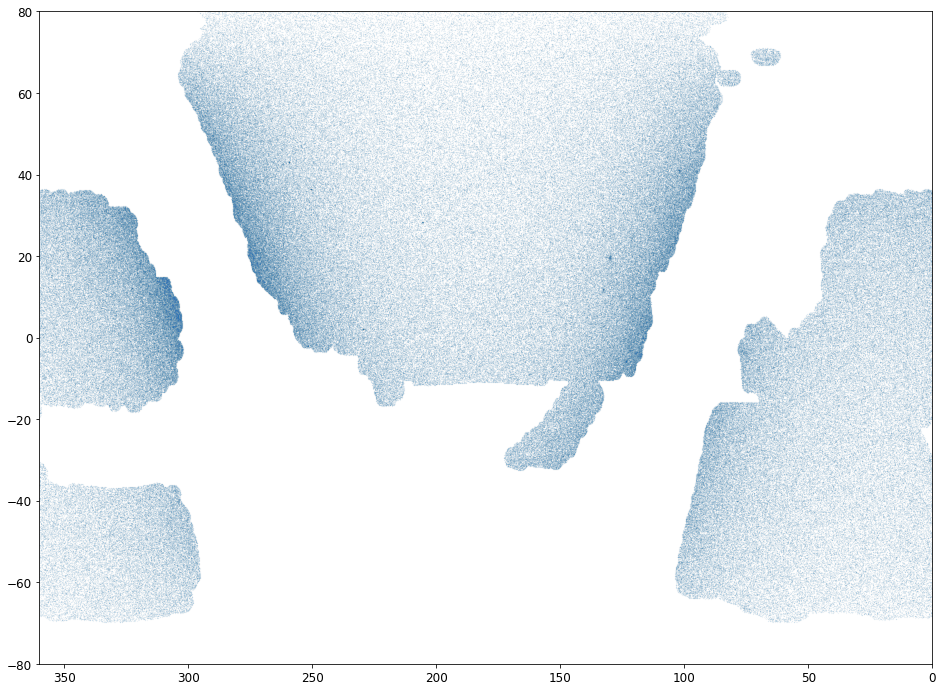

In [4]:
plt.figure(figsize=(16, 12))
plt.plot(twomass['RA'], twomass['DEC'], '.', ms=0.1, alpha=0.5)
plt.gca().invert_xaxis()
plt.axis([360, 0, -80, 80])
plt.show()

In [5]:
tycho2 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/Tycho-2-dr9.fits'))

mask = tycho2['VTmag']<10
tycho2 = tycho2[mask]
print(len(tycho2))

126232


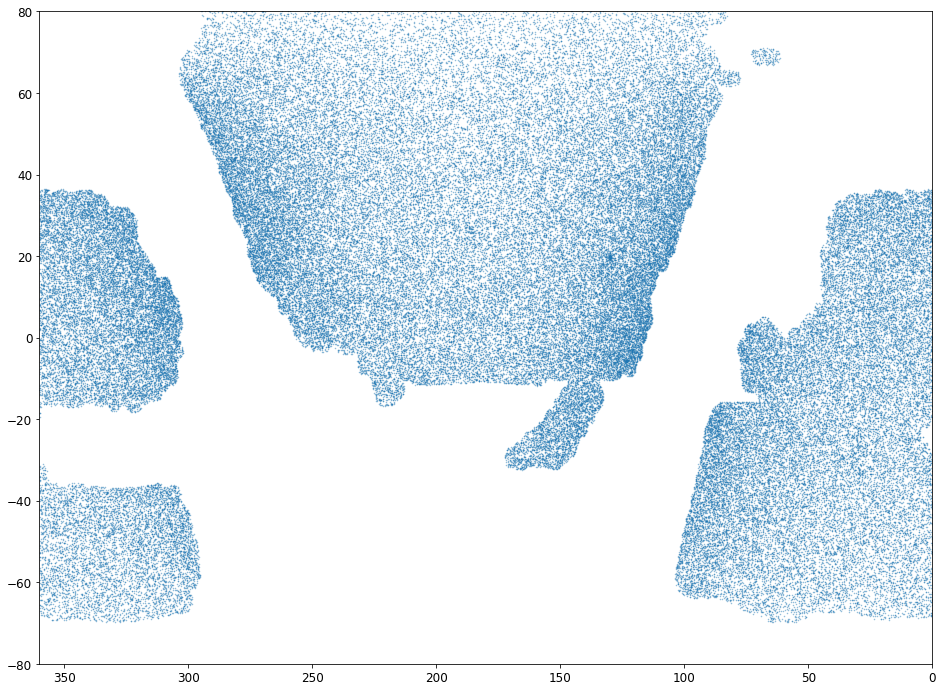

In [6]:
plt.figure(figsize=(16, 12))
plt.plot(tycho2['RA'], tycho2['DEC'], '.', ms=1, alpha=0.5)
plt.gca().invert_xaxis()
plt.axis([360, 0, -80, 80])
plt.show()

Doubly matched objects = 580
Final matched objects = 125619


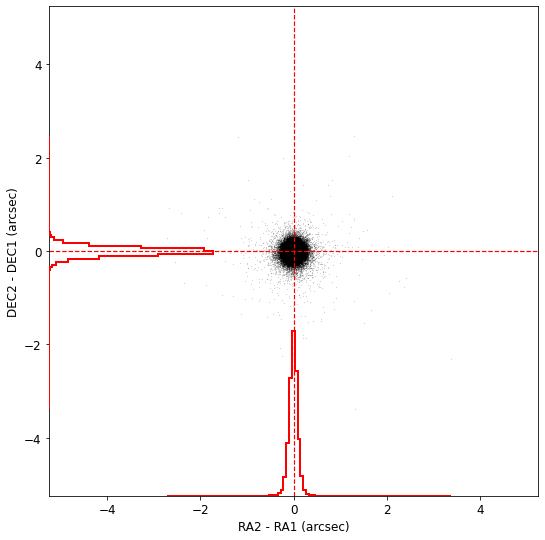

In [7]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord(twomass['RA'], twomass['DEC'], tycho2['RA'], tycho2['DEC'], search_radius=5., plot_q=True)

In [8]:
print(len(idx1)/len(twomass))
print(len(idx1)/len(tycho2))

0.16317376936745956
0.9951438620951898


In [9]:
mask_missing = np.full(len(tycho2), True)
mask_missing[idx2] = False
print(np.sum(mask_missing), np.sum(mask_missing)/len(tycho2))

613 0.004856137904810191


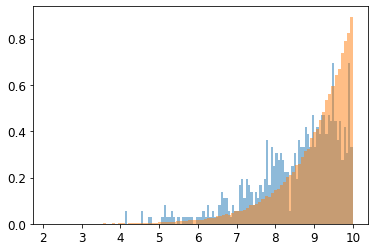

In [10]:
plt.hist(tycho2['VTmag'][mask_missing], 100, density=True, alpha=0.5)
plt.hist(tycho2['VTmag'][~mask_missing], 100, density=True, alpha=0.5)
plt.show()

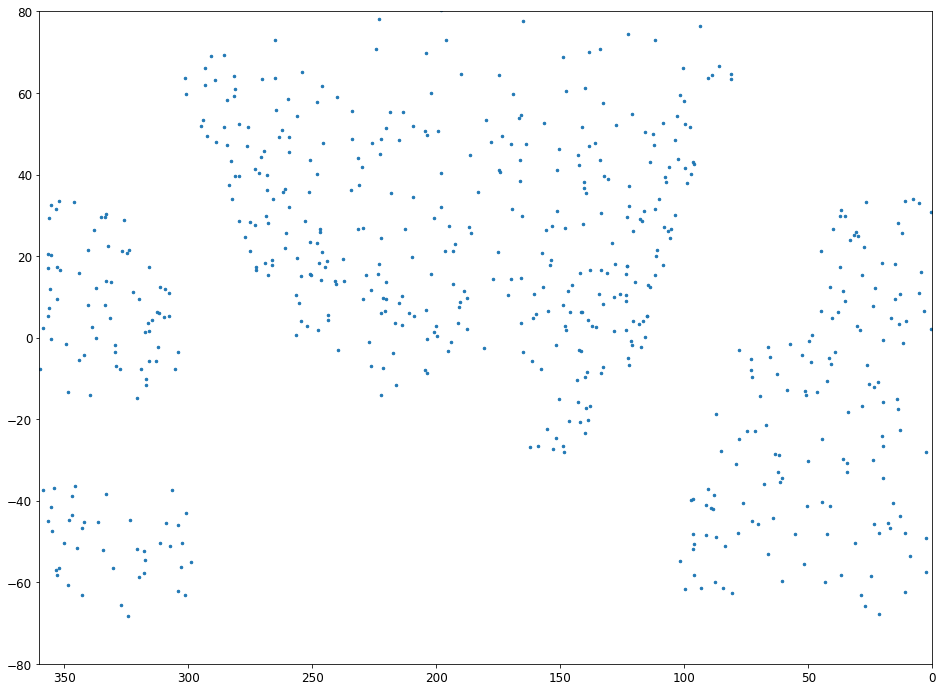

In [11]:
plt.figure(figsize=(16, 12))
plt.plot(tycho2['RA'][mask_missing], tycho2['DEC'][mask_missing], '.', ms=5, alpha=1)
plt.gca().invert_xaxis()
plt.axis([360, 0, -80, 80])
plt.show()

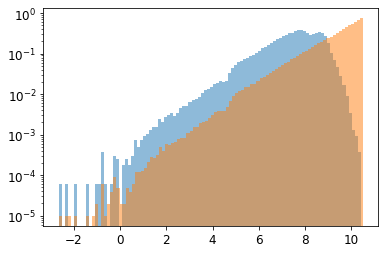

In [12]:
plt.hist(twomass['Jmag'][idx1], 100, alpha=0.5, density=True, log=True)
plt.hist(twomass['Jmag'], 100, alpha=0.5, density=True, log=True)
plt.show()

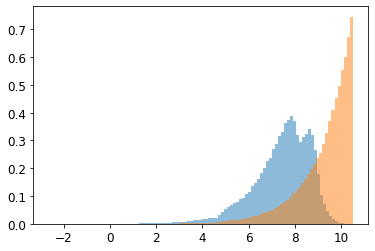

In [13]:
plt.hist(twomass['Jmag'][idx1], 100, alpha=0.5, density=True)
plt.hist(twomass['Jmag'], 100, alpha=0.5, density=True)
plt.show()

In [14]:
twomass = twomass[idx1]
tycho2 = tycho2[idx2]

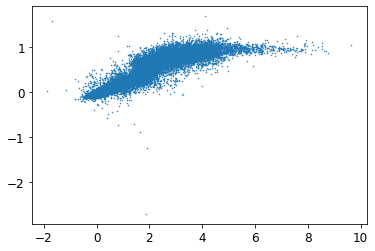

In [22]:
plt.plot(tycho2['VTmag']-twomass['Jmag'], twomass['Jmag']-twomass['Hmag'], '.', ms=1)
plt.show()

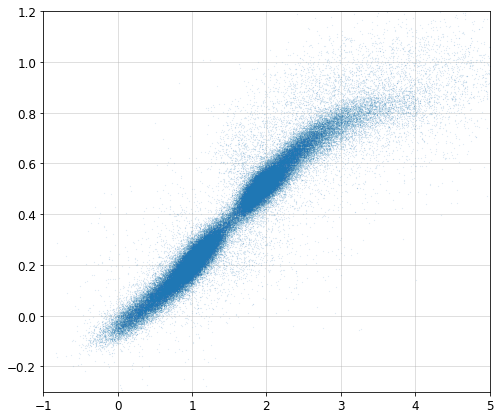

In [26]:
plt.figure(figsize=(8, 7))
plt.plot(tycho2['VTmag']-twomass['Jmag'], twomass['Jmag']-twomass['Hmag'], '.', ms=0.1)
plt.axis([-1, 5, -0.3, 1.2])
plt.grid(alpha=0.5)
plt.show()